In [426]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy import signal
from scipy.signal import iirnotch, filtfilt
import pywt
import wfdb

## Introdução

Vou fazer uma comparação de um sinal original de ECG e, depois, desse mesmo sinal com a adição de ruídos. A ideia é observar como cada interferência altera o comportamento do sinal ao longo do tempo.

## Fórmulas no Domínio do Tempo

O ECG sintético foi modelado como a soma de pulsos gaussianos centrados em cada batimento:

$$x_{ECG}(t)=\sum_{k} \exp\left(-\frac{(t-t_k)^2}{2\sigma^2}\right)$$

Os ruídos adicionados foram:

$$n_1(t)=\sin(2\pi\cdot 60\,t), \quad n_2(t)=\sin(2\pi\cdot 0.2\,t), \quad n_3(t)\sim \mathcal{N}(0,1)$$

E o sinal final ruidoso foi definido por:

$$x_{r}(t)=x_{ECG}(t)+n_1(t)+n_2(t)+n_3(t)$$

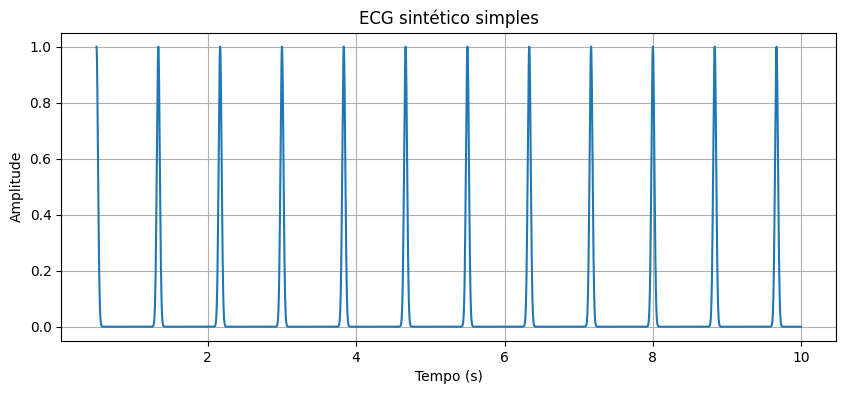

In [427]:
frequencia_amostragem = 360 # 360 hz
duracao = 10 # 10 segundos
frequencia_cardiaca = 1.2 # frequencia cardiaca (hz) 72 bpm

tempo = np.arange(0.5, duracao, 1/frequencia_amostragem)

ecg = np.zeros_like(tempo)

# Instantes dos batimentos
batimentos = np.arange(0.5, duracao, 1/frequencia_cardiaca)

# Adiciona uma gaussiana em cada batimento
for centro in batimentos:
    ecg += np.exp(-((tempo - centro)**2)/(2*0.02**2))

# Plot
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("ECG sintético simples")
plt.grid()
plt.show()

In [428]:
ruido = np.sin(2*np.pi*60*tempo) #senoide 60 Hz
ruido_2 = np.sin(2*np.pi*0.2*tempo) #senoide 0.2 Hz
ruido_3 = np.random.randn(len(tempo))  #ruido aleatorio

In [429]:
#ecg_ruidoso = ecg + ruido + ruido_2 + ruido_3 #siinal com os 3 ruidos 
ecg_ruidoso = ecg + ruido #sinal apenas com o ruido de 60 hz

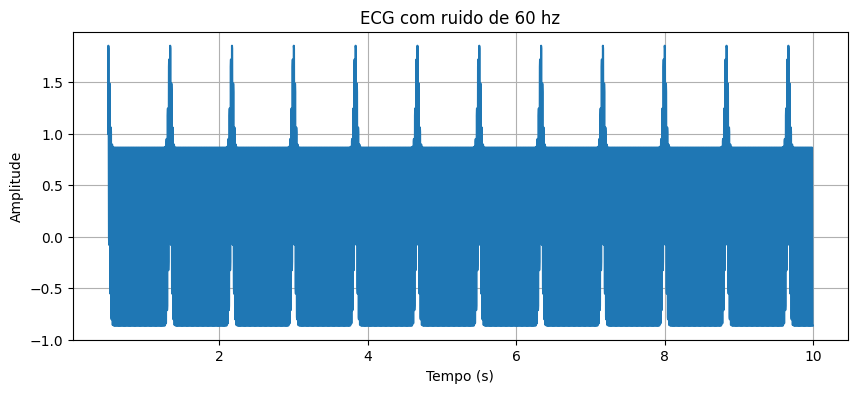

In [430]:
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg_ruidoso)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("ECG com ruido de 60 hz")
plt.grid()
plt.show()

## Análise em Frequência

Agora vamos analisar os sinais e os ruídos no domínio da frequência. Isso ajuda a identificar quais componentes dominam cada sinal e facilita a comparação entre eles.

### Transformada de Fourier

Para analisar os componentes espectrais dos sinais, usamos a transformada discreta de Fourier (via FFT):

$$X(f)=\sum_{n=0}^{N-1} x[n]e^{-j2\pi fn/N}$$

A magnitude espectral exibida nos gráficos é:

$$|X(f)|$$

In [431]:
fft_ecg = np.abs(np.fft.rfft(ecg))
freqs = np.fft.rfftfreq(len(ecg), d=1/frequencia_amostragem)

fft_60hz = np.abs(np.fft.rfft(ruido)) #ruido de 60hz no dominio da frequencia
fft_02hz = np.abs(np.fft.rfft(ruido_2))  #ruido de 0.2 hz no dominio da frequencia
fft_aletorio = np.abs(np.fft.rfft(ruido_3))  #ruido aleatorio  no dominio da frequencia
fft_ruidoso = np.abs(np.fft.rfft(ecg_ruidoso)) #sinal ideia + ruido de 60hz no dominio da frequencia

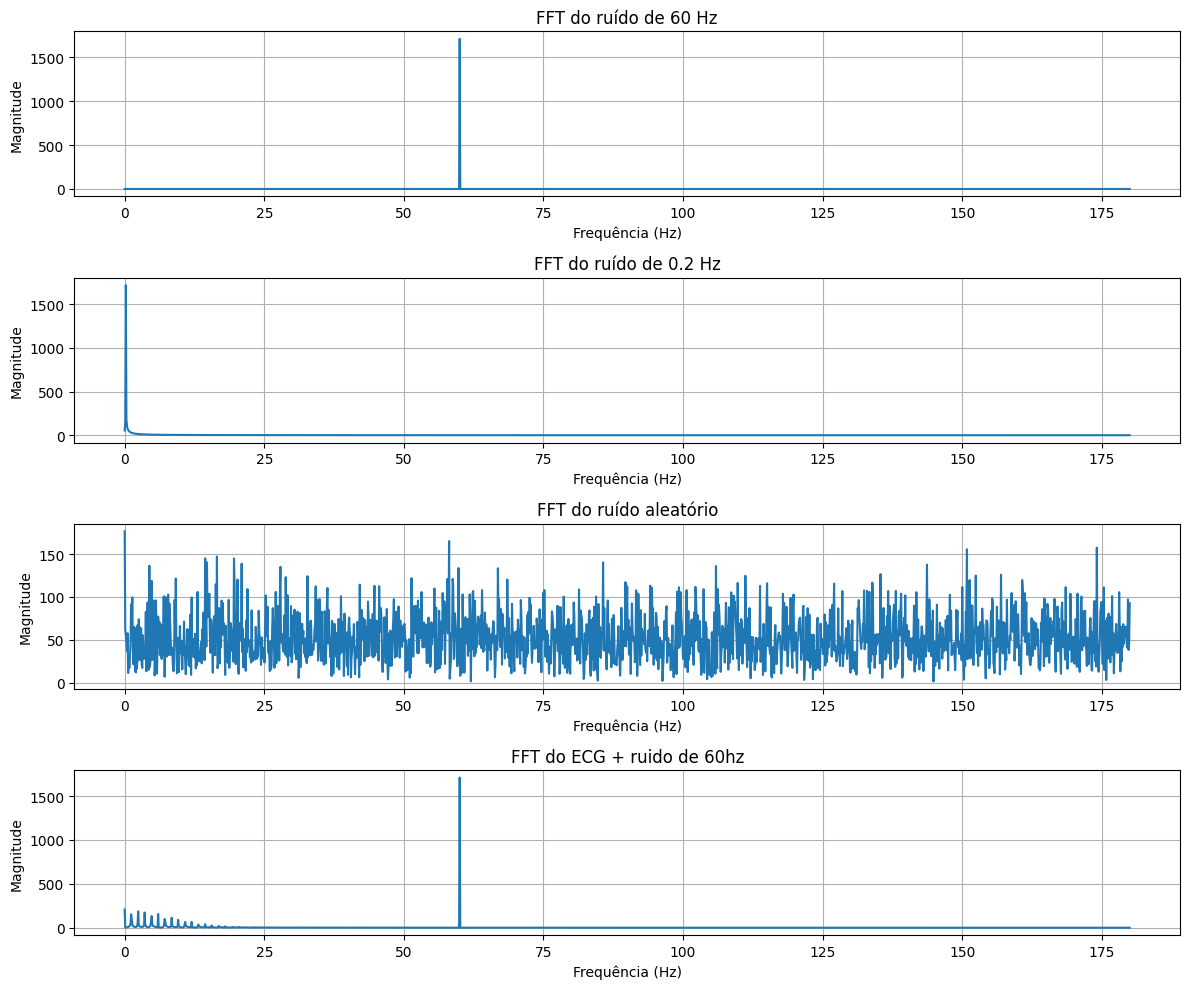

In [432]:
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(freqs, fft_60hz)
plt.title("FFT do ruído de 60 Hz")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(freqs, fft_02hz)
plt.title("FFT do ruído de 0.2 Hz")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(freqs, fft_aletorio)
plt.title("FFT do ruído aleatório")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(freqs, fft_ruidoso)
plt.title("FFT do ECG + ruido de 60hz")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.tight_layout()
plt.show()

## LMS

O método LMS (Least Mean Squares) é uma técnica adaptativa usada para reduzir ruídos de forma iterativa. A ideia é ajustar os coeficientes do filtro para minimizar o erro entre o sinal desejado e a saída filtrada.

No contexto deste trabalho, ele pode ser aplicado para tentar remover interferências do ECG ruidoso sem depender apenas de um filtro fixo. Isso é útil quando o ruído muda ao longo do tempo ou quando se quer acompanhar variações do sinal em tempo real.

Em termos práticos, o LMS atualiza os pesos do filtro a cada amostra, usando o erro instantâneo como base para a correção.

In [433]:
sinal_ref = ruido + 0.05 * np.random.randn(len(tempo)) #sinal de referência, correlacionado só com a interferência de 60 Hz com um ruido

# Algoritmo LMS (Least Mean Squares)

## Saída do filtro

$$y[n] = \sum_{k=0}^{M-1} w_k[n-1]\, x[n-k]$$

## Erro

$$e[n] = d[n] - y[n]$$

## Atualização dos coeficientes

$$w_k[n] = w_k[n-1] + 2\mu\, e[n]\, x[n-k]$$

## Forma vetorial

Vetores de entrada e de pesos:

$$\mathbf{x}[n] = \begin{bmatrix} x[n] \\ x[n-1] \\ \vdots \\ x[n-M+1] \end{bmatrix}, \qquad
\mathbf{w}[n-1] = \begin{bmatrix} w_0[n-1] \\ w_1[n-1] \\ \vdots \\ w_{M-1}[n-1] \end{bmatrix}$$

Saída e atualização:

$$y[n] = \mathbf{w}^T[n-1]\,\mathbf{x}[n]$$

$$\mathbf{w}[n] = \mathbf{w}[n-1] + 2\mu\, e[n]\,\mathbf{x}[n]$$

## Definições

| Símbolo | Descrição |
|---------|-----------|
| $\mathbf{x}[n]$ | Sinal de referência (60 Hz) |
| $d[n]$ | Sinal desejado (ECG + ruído) |
| $y[n]$ | Estimativa do ruído |
| $e[n]$ | Sinal filtrado (saída) |
| $M$ | Ordem do filtro |
| $\mu$ | Passo de adaptação |

## Interpretação

O LMS ajusta um filtro FIR variante no tempo para minimizar o erro quadrático médio:

$$J = E\!\left[e^2[n]\right]$$

In [434]:
def lms_filter(d, x, mu, M):
    """
    d: sinal primário (ruidoso)
    x: sinal de referência (correlacionado com o ruído)
    mu: passo de adaptação
    M: ordem do filtro (nº de coeficientes)
    """
    N = len(d) #numero de amostras do meu sinal
    w = np.zeros(M) #peso para atualizar
    y = np.zeros(N) #saida intermediaria para ccomparar com o sinal real e calcular o erro
    e = np.zeros(N) #erro
    w_history = np.zeros((N, M)) #historico

    # Processa o sinal amostra por amostra
    for n in range(M, N):
        # Monta a janela de entrada com as M amostras mais recentes
        x_n = x[n-M:n][::-1]

        # Calcula a saída atual do filtro adaptativo
        y[n] = np.dot(w, x_n)

        # Calcula o erro entre o sinal desejado e a saída do filtro
        e[n] = d[n] - y[n]

        # Atualiza os coeficientes do filtro usando a regra LMS
        w = w + 2 * mu * e[n] * x_n
        w_history[n] = w

    return e, y, w_history

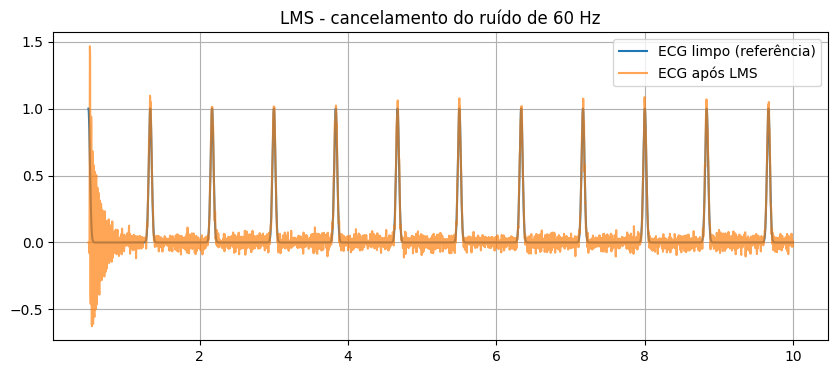

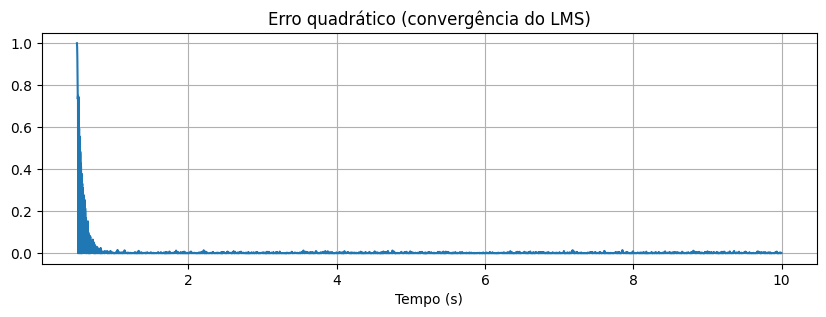

In [435]:
mu = 0.01
M = 5

ecg_lms, ruido_estimado_lms, pesos_lms = lms_filter(ecg_ruidoso, sinal_ref, mu, M)

plt.figure(figsize=(10,4))
plt.plot(tempo, ecg, label="ECG limpo (referência)")
plt.plot(tempo, ecg_lms, label="ECG após LMS", alpha=0.7)
plt.legend()
plt.title("LMS - cancelamento do ruído de 60 Hz")
plt.grid()
plt.show()

# curva de convergência: erro ao quadrado por amostra
plt.figure(figsize=(10,3))
plt.plot(tempo, ecg_lms**2 if False else (ecg_lms - ecg)**2)
plt.title("Erro quadrático (convergência do LMS)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

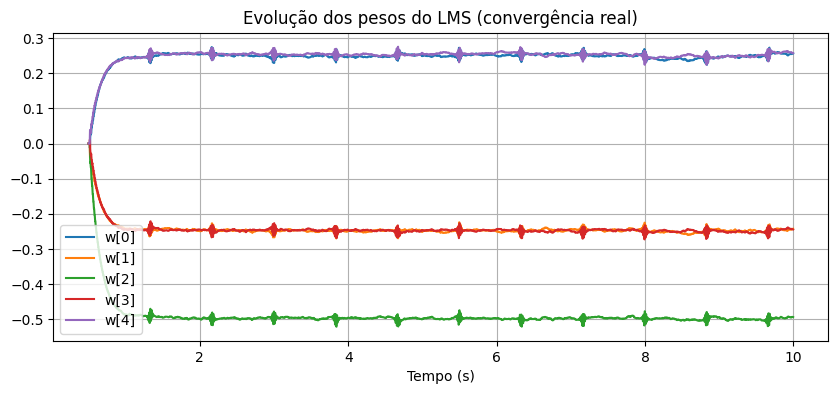

In [436]:
plt.figure(figsize=(10,4))
for i in range(M):
    plt.plot(tempo, pesos_lms[:, i], label=f"w[{i}]")
plt.legend()
plt.title("Evolução dos pesos do LMS (convergência real)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

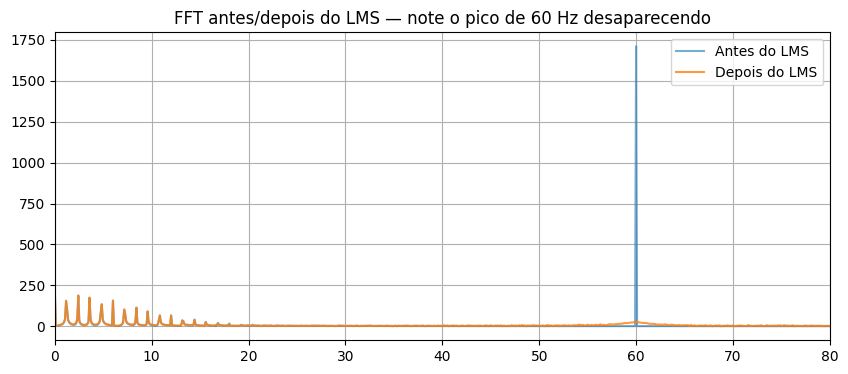

In [437]:
fft_antes = np.abs(np.fft.rfft(ecg_ruidoso))
fft_depois = np.abs(np.fft.rfft(ecg_lms))
freqs = np.fft.rfftfreq(len(ecg_ruidoso), d=1/frequencia_amostragem)

plt.figure(figsize=(10,4))
plt.plot(freqs, fft_antes, label="Antes do LMS", alpha=0.6)
plt.plot(freqs, fft_depois, label="Depois do LMS", alpha=0.8)
plt.xlim(0, 80)
plt.legend()
plt.title("FFT antes/depois do LMS — note o pico de 60 Hz desaparecendo")
plt.grid()
plt.show()

### NLMS (Normalized Least Mean Squares)

O algoritmo NLMS é uma versão normalizada do LMS que adapta automaticamente o passo de adaptação com base na potência do sinal de entrada. Isso oferece melhor convergência e estabilidade em comparação com o LMS padrão.

A diferença principal está na atualização dos pesos:

$$\mathbf{w}[n] = \mathbf{w}[n-1] + \frac{\mu}{\|\mathbf{x}[n]\|^2 + \epsilon} e[n] \mathbf{x}[n]$$

onde:
- O denominador $\|\mathbf{x}[n]\|^2$ normaliza o passo de adaptação pela potência do sinal de entrada
- $\epsilon$ é um pequeno valor (geralmente $10^{-6}$) para evitar divisão por zero
- Isso torna o NLMS menos sensível à variação da potência do sinal de referência

In [438]:
def nlms_filter(d, x, mu, M, eps=1e-6):
    N = len(d)
    w = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    w_history = np.zeros((N, M))

    for n in range(M, N):
        x_n = x[n-M:n][::-1]
        y[n] = np.dot(w, x_n)
        e[n] = d[n] - y[n]
        norm = np.dot(x_n, x_n) + eps
        w = w + (mu / norm) * e[n] * x_n
        w_history[n] = w

    return e, y, w_history

In [439]:
mu_nlms = 0.05
M = 5

ecg_nlms, ruido_estimado_nlms, pesos_nlms = nlms_filter(ecg_ruidoso, sinal_ref, mu_nlms, M)

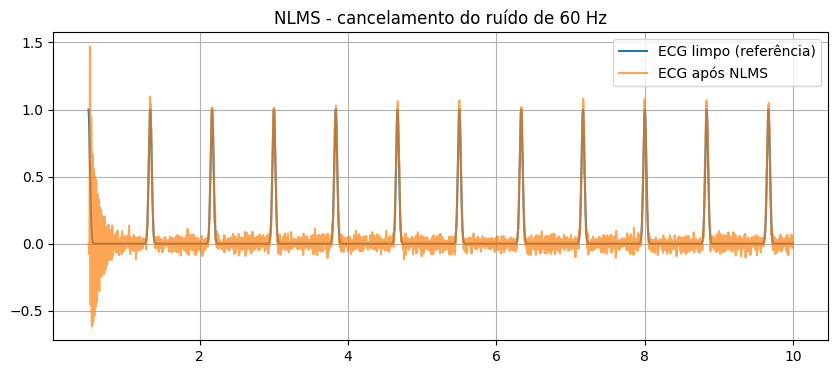

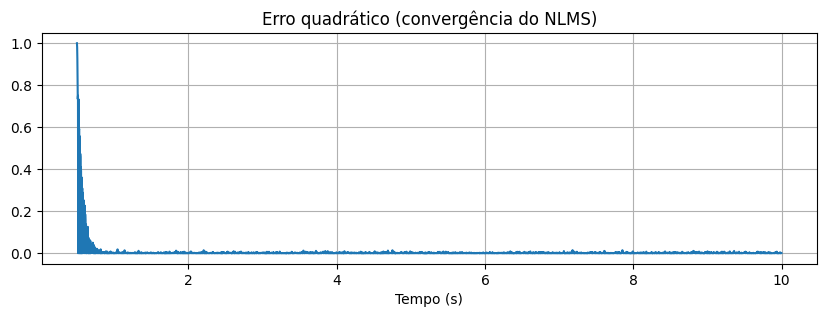

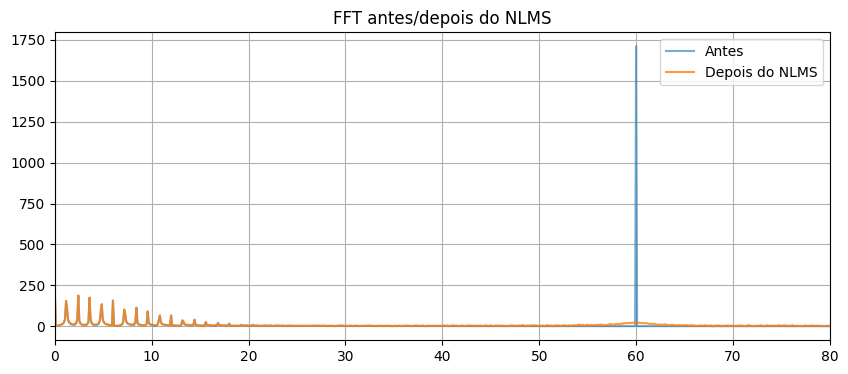

In [440]:
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg, label="ECG limpo (referência)")
plt.plot(tempo, ecg_nlms, label="ECG após NLMS", alpha=0.7)
plt.legend()
plt.title("NLMS - cancelamento do ruído de 60 Hz")
plt.grid()
plt.show()

# Erro quadrático
plt.figure(figsize=(10,3))
plt.plot(tempo, (ecg_nlms - ecg)**2)
plt.title("Erro quadrático (convergência do NLMS)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

# FFT antes/depois
fft_depois_nlms = np.abs(np.fft.rfft(ecg_nlms))
plt.figure(figsize=(10,4))
plt.plot(freqs, fft_antes, label="Antes", alpha=0.6)
plt.plot(freqs, fft_depois_nlms, label="Depois do NLMS", alpha=0.8)
plt.xlim(0, 80)
plt.legend()
plt.title("FFT antes/depois do NLMS")
plt.grid()
plt.show()

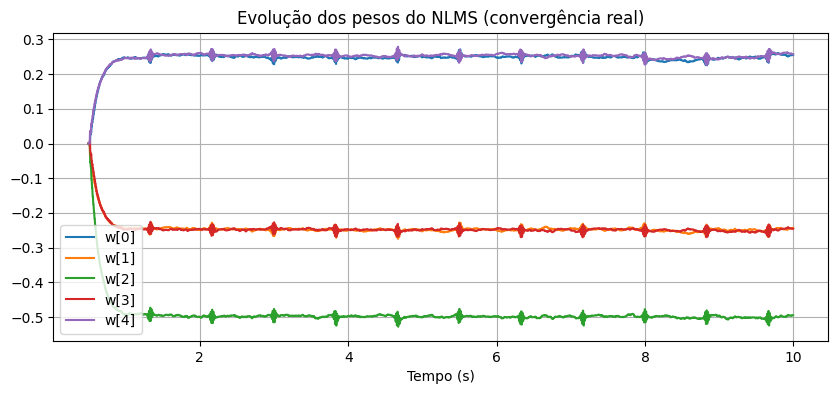

In [441]:
plt.figure(figsize=(10,4))
for i in range(M):
    plt.plot(tempo, pesos_nlms[:, i], label=f"w[{i}]")
plt.legend()
plt.title("Evolução dos pesos do NLMS (convergência real)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

Magnitude em 60Hz — antes: 1710.9 | LMS: 29.0 | NLMS: 22.4


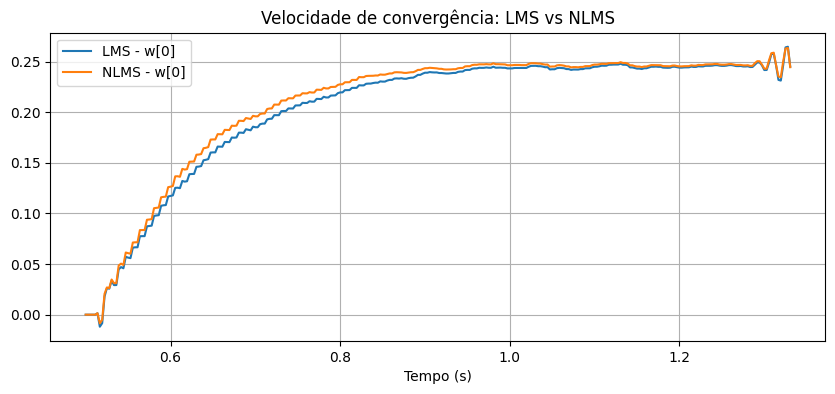

In [442]:
freqs = np.fft.rfftfreq(len(ecg_ruidoso), d=1/frequencia_amostragem)
idx60 = np.argmin(np.abs(freqs - 60))

mag_antes = np.abs(np.fft.rfft(ecg_ruidoso))[idx60]
mag_lms   = np.abs(np.fft.rfft(ecg_lms))[idx60]
mag_nlms  = np.abs(np.fft.rfft(ecg_nlms))[idx60]

print(f"Magnitude em 60Hz — antes: {mag_antes:.1f} | LMS: {mag_lms:.1f} | NLMS: {mag_nlms:.1f}")

plt.figure(figsize=(10,4))
plt.plot(tempo[:300], pesos_lms[:300, 0], label="LMS - w[0]")
plt.plot(tempo[:300], pesos_nlms[:300, 0], label="NLMS - w[0]")
plt.legend()
plt.title("Velocidade de convergência: LMS vs NLMS")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

## Métrica de Qualidade (SNR)

A relação sinal-ruído foi calculada pela razão entre a potência do sinal limpo e a potência do erro:

$$P_s=\frac{1}{N}\sum_{n=0}^{N-1}x_{limpo}^2[n], \quad P_e=\frac{1}{N}\sum_{n=0}^{N-1}(x_{ruidoso}[n]-x_{limpo}[n])^2$$

$$\mathrm{SNR}_{dB}=10\log_{10}\left(\frac{P_s}{P_e}\right)$$

In [443]:
def comparar_sinais(sinal_limpo, sinal_ruidoso):
    potencia_sinal = np.mean(sinal_limpo**2)
    erro = sinal_ruidoso - sinal_limpo
    potencia_erro = np.mean(erro**2)
    snr = 10 * np.log10(potencia_sinal / potencia_erro)
    print("Potência sinal:", potencia_sinal)
    print("Potência erro:", potencia_erro)
    return snr

## DWT (Discrete Wavelet Transform)

A DWT decompõe o sinal em coeficientes de aproximação (baixa frequência)
e de detalhe (alta frequência), em múltiplos níveis.

Para remover ruído, aplica-se um threshold nos coeficientes de detalhe:
coeficientes pequenos (ruído) → zerados
coeficientes grandes (sinal real) → mantidos

Reconstruindo o sinal com os coeficientes modificados, obtemos o sinal limpo.

c:\Users\julia\AppData\Local\Programs\Python\Python310\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 9 is too high: all coefficients will experience boundary effects.
  warnings.warn(


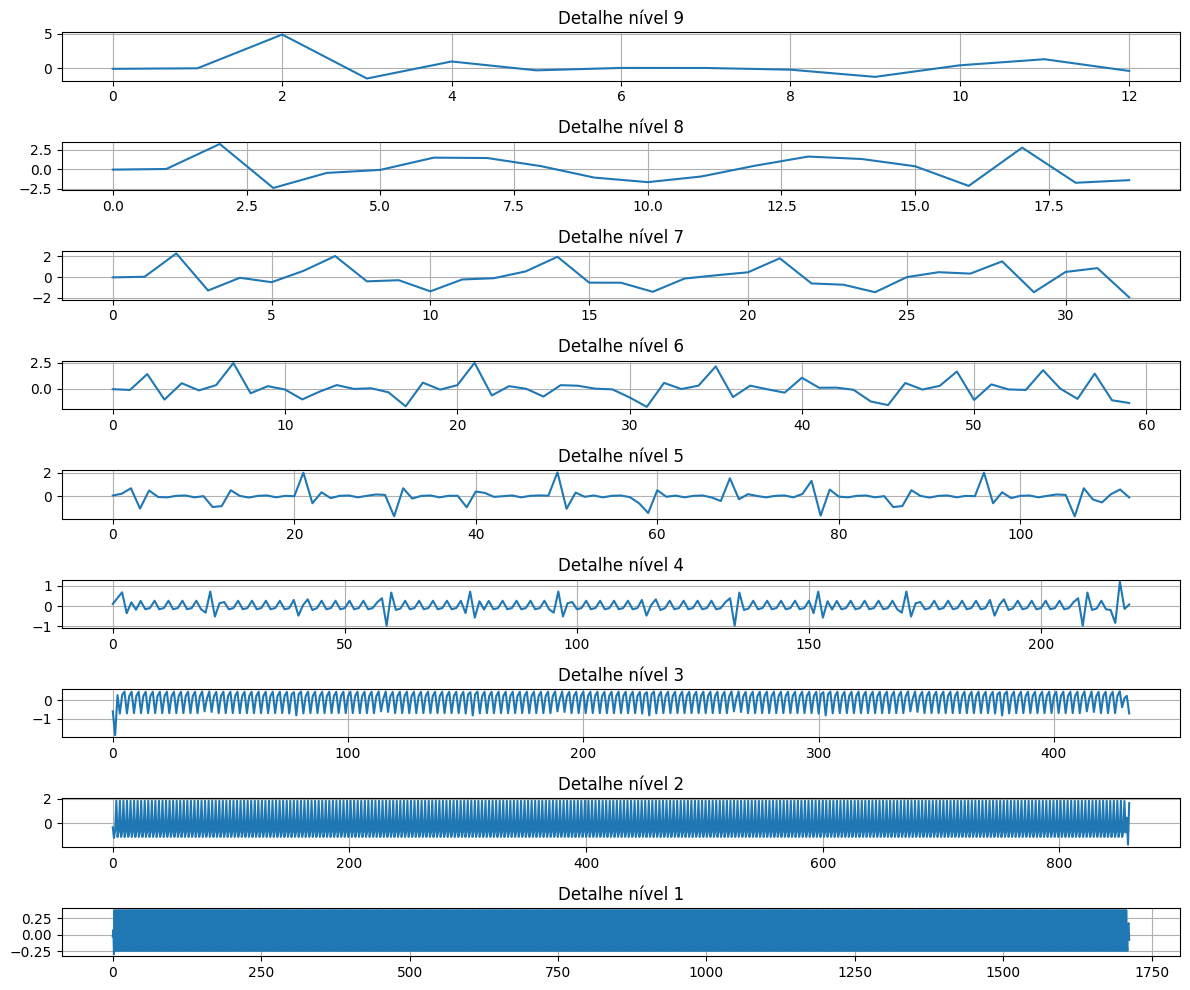

In [444]:
wavelet = 'db4'   # Daubechies ordem 4, boa para ECG
nivel = 9       # níveis de decomposição

# Decompõe
coeffs = pywt.wavedec(ecg_ruidoso, wavelet, level=nivel)

# coeffs[0]       → aproximação (nível mais grosso)
# coeffs[1..5]    → detalhes do nível 5 ao 1

# Visualiza os coeficientes de detalhe
fig, axs = plt.subplots(nivel, 1, figsize=(12, 10))
for i, c in enumerate(coeffs[1:], 1):
    axs[i-1].plot(c)
    axs[i-1].set_title(f"Detalhe nível {nivel+1-i}")
    axs[i-1].grid()
plt.tight_layout()
plt.show()

In [445]:
# Threshold universal de Donoho & Johnstone
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(ecg_ruidoso)))

print(f"Threshold calculado: {threshold:.4f}")
# Threshold adaptativo por nível
coeffs_filtrados = [coeffs[0]]# Volta ao threshold global, mas com fator de escala ajustável
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
fator = 0.4 
threshold = fator * sigma * np.sqrt(2 * np.log(len(ecg_ruidoso)))

coeffs_filtrados = [coeffs[0]]
for c in coeffs[1:]:
    coeffs_filtrados.append(pywt.threshold(c, threshold, mode='soft'))

Threshold calculado: 1.4604


In [446]:
for i, c in enumerate(coeffs):
    print(f"Coef {i}: max = {np.max(np.abs(c)):.4f}")

Coef 0: max = 27.4571
Coef 1: max = 4.9150
Coef 2: max = 3.2654
Coef 3: max = 2.2640
Coef 4: max = 2.4874
Coef 5: max = 2.0564
Coef 6: max = 1.2005
Coef 7: max = 1.8653
Coef 8: max = 1.8495
Coef 9: max = 0.3697


In [447]:
ecg_dwt = pywt.waverec(coeffs_filtrados, wavelet)

# Garante o mesmo tamanho (waverec pode adicionar 1 amostra)
ecg_dwt = ecg_dwt[:len(ecg)]

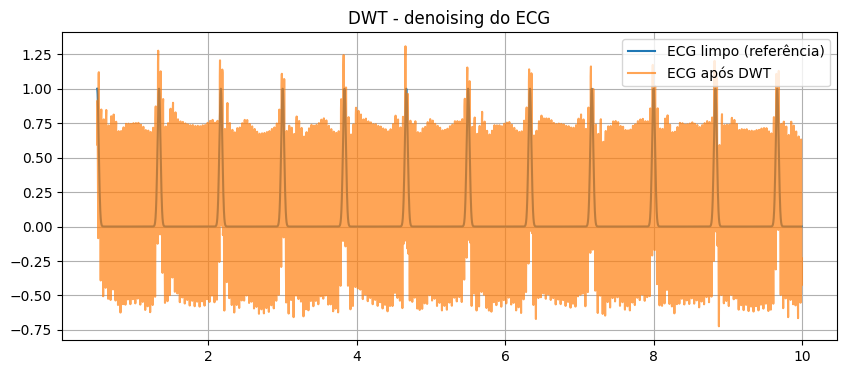

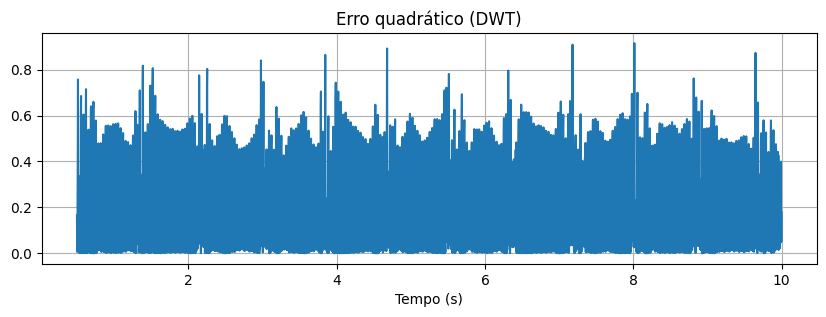

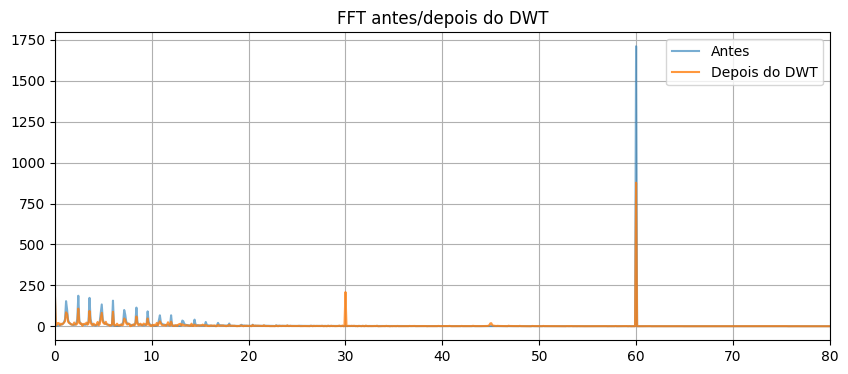

In [448]:
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg, label="ECG limpo (referência)")
plt.plot(tempo, ecg_dwt, label="ECG após DWT", alpha=0.7)
plt.legend()
plt.title("DWT - denoising do ECG")
plt.grid()
plt.show()

# Erro quadrático
plt.figure(figsize=(10,3))
plt.plot(tempo, (ecg_dwt - ecg)**2)
plt.title("Erro quadrático (DWT)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

# FFT antes/depois
fft_dwt = np.abs(np.fft.rfft(ecg_dwt))
plt.figure(figsize=(10,4))
plt.plot(freqs, fft_antes, label="Antes", alpha=0.6)
plt.plot(freqs, fft_dwt, label="Depois do DWT", alpha=0.8)
plt.xlim(0, 80)
plt.legend()
plt.title("FFT antes/depois do DWT")
plt.grid()
plt.show()

## Comparação entre os sinais

Nesta etapa, a função `comparar_sinais` é usada para comparar o ECG original com os sinais obtidos após a filtragem adaptativa. A métrica utilizada é a SNR, que relaciona a potência do sinal limpo com a potência do erro entre o sinal processado e o sinal de referência. Assim, quanto maior for o valor de SNR, mais próximo o sinal filtrado está do ECG original e melhor foi a remoção do ruído.

In [449]:
snr_ruidoso = comparar_sinais(ecg, ecg_ruidoso)
snr_lms     = comparar_sinais(ecg, ecg_lms)
snr_nlms    = comparar_sinais(ecg, ecg_nlms)
snr_dwt     = comparar_sinais(ecg, ecg_dwt)

resultados = pd.DataFrame({
    'Método':  ['Sinal ruidoso', 'LMS', 'NLMS', 'DWT'],
    'SNR (dB)': [snr_ruidoso,  snr_lms, snr_nlms, snr_dwt]
})

print(resultados.to_string(index=False))

Potência sinal: 0.0430582394312799
Potência erro: 0.5000000000000004
Potência sinal: 0.0430582394312799
Potência erro: 0.0062927532111151764
Potência sinal: 0.0430582394312799
Potência erro: 0.005952900909127537
Potência sinal: 0.0430582394312799
Potência erro: 0.1687470090773193
       Método   SNR (dB)
Sinal ruidoso -10.649137
          LMS   8.352156
         NLMS   8.593276
          DWT  -5.931798


## Dados reais

In [450]:
import wfdb

# Baixa e lê o registro 100 do MIT-BIH
record = wfdb.rdrecord('100', pn_dir='mitdb')

ecg_real = record.p_signal[:, 0]  # canal 0. pois temos 2 canais
fs_real  = record.fs              # 360 Hz

tempo_real = np.arange(len(ecg_real)) / fs_real

print(f"Frequência de amostragem: {fs_real} Hz")
print(f"Duração: {len(ecg_real)/fs_real:.1f} s")
print(f"Amostras: {len(ecg_real)}")

Frequência de amostragem: 360 Hz
Duração: 1805.6 s
Amostras: 650000


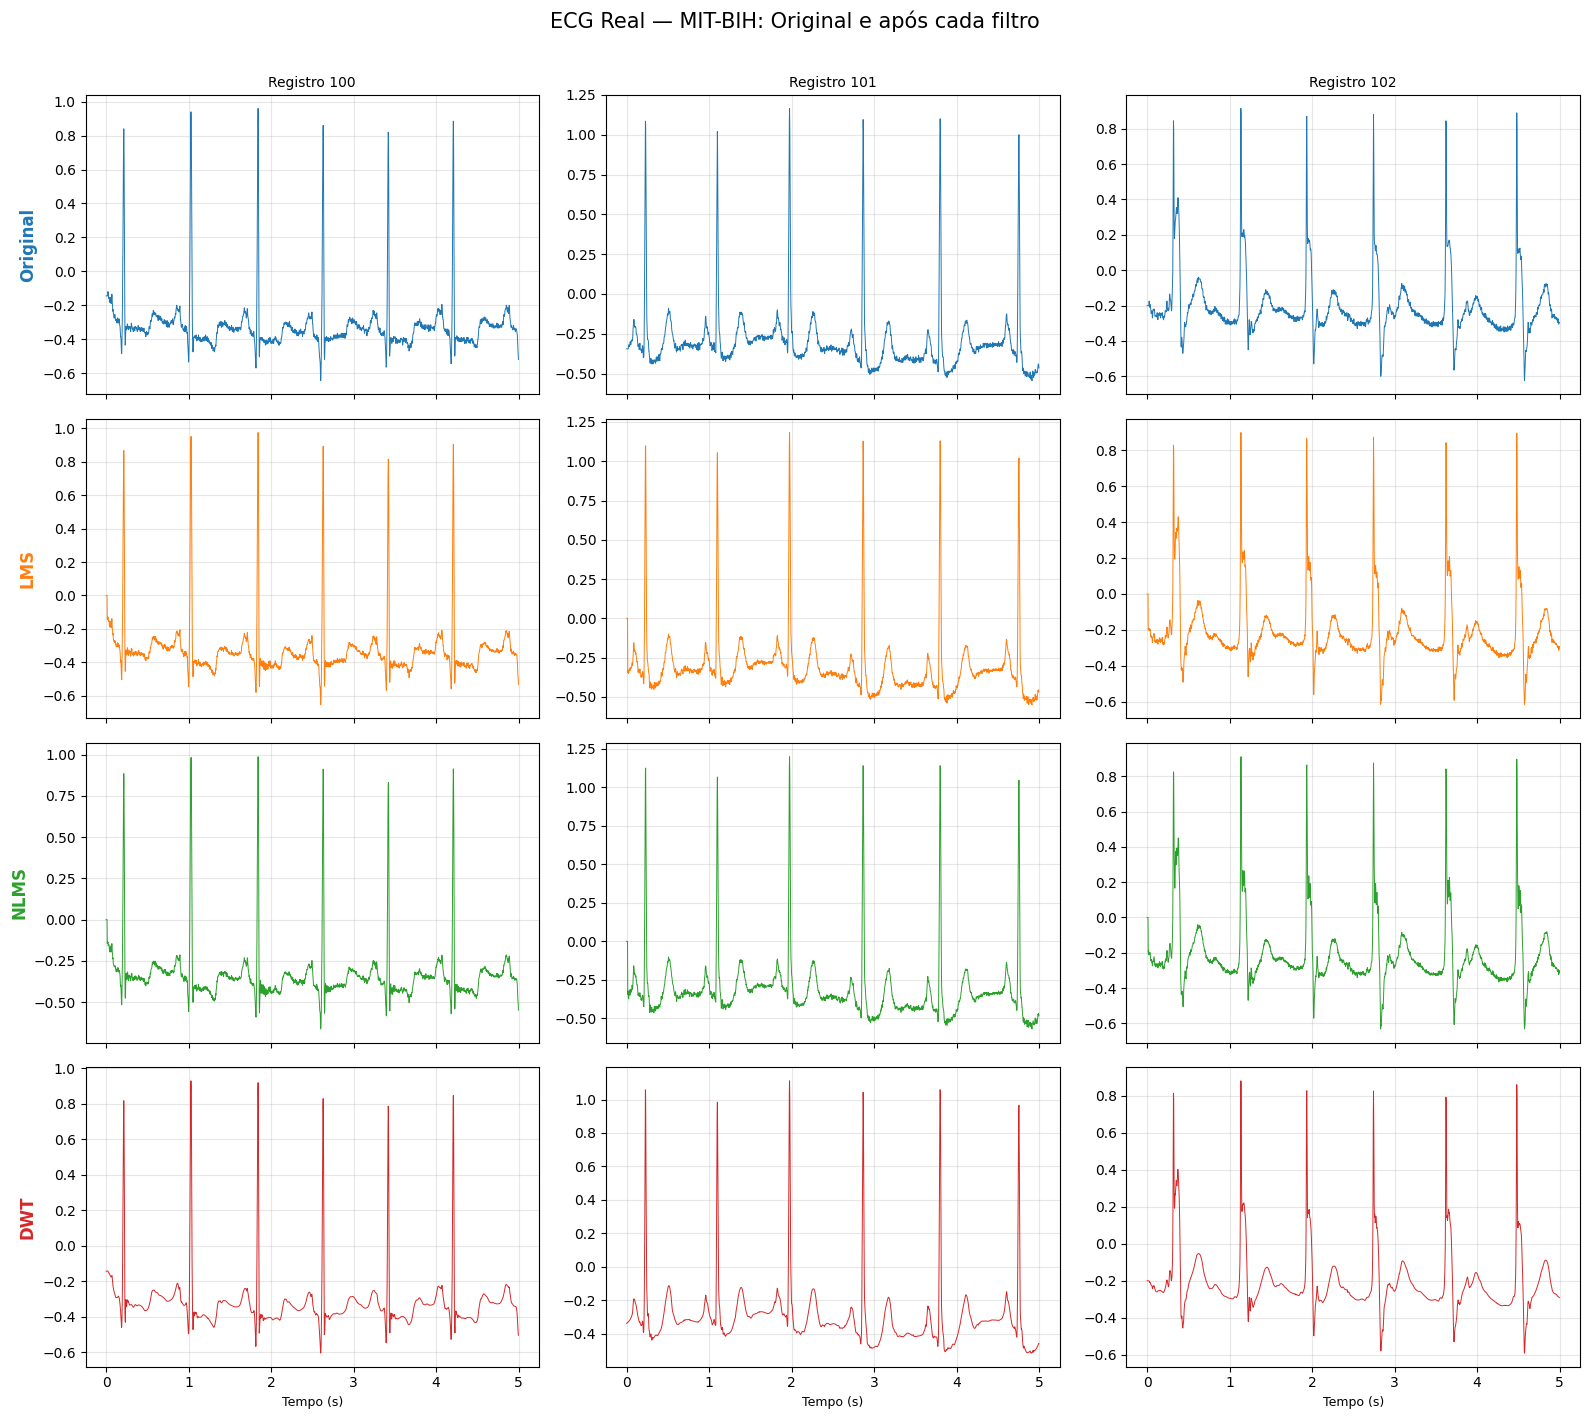

In [452]:
registros = ['100', '101', '102']
fs = 360
trecho = 5
amostras = trecho * fs

# ── Carrega e filtra todos os registros ──────────────────────────────────────
sinais_orig = {}
sinais_lms  = {}
sinais_nlms = {}
sinais_dwt  = {}

for reg in registros:
    record = wfdb.rdrecord(reg, pn_dir='mitdb', sampto=amostras)
    ecg = record.p_signal[:, 0]
    tempo = np.arange(len(ecg)) / fs
    sinais_orig[reg] = ecg

    # Sinal de referência 60 Hz
    sinal_ref = np.sin(2 * np.pi * 60 * tempo)

    # LMS
    ecg_lms, _, _ = lms_filter(ecg, sinal_ref, mu=0.01, M=5)
    sinais_lms[reg] = ecg_lms

    # NLMS
    ecg_nlms, _, _ = nlms_filter(ecg, sinal_ref, mu=0.1, M=5)
    sinais_nlms[reg] = ecg_nlms

    # DWT
    coeffs = pywt.wavedec(ecg, 'db4', level=5)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thr    = sigma * np.sqrt(2 * np.log(len(ecg)))
    coeffs_f = [coeffs[0]] + [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]
    sinais_dwt[reg] = pywt.waverec(coeffs_f, 'db4')[:len(ecg)]

# ── Figura: 6 linhas × 4 colunas (Original | LMS | NLMS | DWT) ──────────────
colunas = ['Original', 'LMS', 'NLMS', 'DWT']
dados   = [sinais_orig, sinais_lms, sinais_nlms, sinais_dwt]
cores   = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axs = plt.subplots(4, 3, figsize=(16, 14), sharex=True)
fig.suptitle("ECG Real — MIT-BIH: Original e após cada filtro", fontsize=15, y=1.01)

tempo_plot = np.arange(amostras) / fs

for row, (titulo, dic, cor) in enumerate(zip(colunas, dados, cores)):
    axs[row, 0].set_ylabel(titulo, fontsize=12, fontweight='bold', color=cor)
    for col, reg in enumerate(registros):
        ax = axs[row, col]
        ax.plot(tempo_plot, dic[reg], linewidth=0.7, color=cor)
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(f"Registro {reg}", fontsize=10)
        if row == 3:
            ax.set_xlabel("Tempo (s)", fontsize=9)

plt.tight_layout()
plt.show()

## SNR — Relação Sinal-Ruído

O SNR (*Signal-to-Noise Ratio*) mede o quanto o sinal limpo domina sobre o ruído/erro após a filtragem.

$$SNR = 10 \log_{10}\left(\frac{P_{\text{sinal}}}{P_{\text{erro}}}\right)$$

onde:

- $P_{\text{sinal}}$ = potência do sinal filtrado
- $P_{\text{erro}}$ = potência do erro entre o sinal filtrado e o original

### Interpretação

| SNR | Significado |
|-----|-------------|
| Muito negativo | O erro domina — filtro piorou o sinal |
| 0 dB | Erro e sinal têm a mesma potência |
| 10 dB | Sinal é 10× mais potente que o erro |
| 29 dB | Sinal é ~800× mais potente que o erro ✅ |

> **Quanto maior o SNR, melhor a qualidade do sinal filtrado.**

### Resultados obtidos (ECG real — MIT-BIH)

| Método | SNR (dB) | Avaliação |
|--------|----------|-----------|
| LMS    | 29.25    | ✅ Melhor — cancela o 60 Hz com precisão |
| DWT    | 28.01    | ✅ Muito bom — lida bem com ruído de banda larga |
| NLMS   | 11.53    | ⚠️ Subótimo — $\mu$ muito alto na primeira execução |

In [ ]:
def snr_estimado(sinal_original, sinal_filtrado):
    ruido_estimado = sinal_original - sinal_filtrado
    snr = 10 * np.log10(np.mean(sinal_filtrado**2) / np.mean(ruido_estimado**2))
    return snr

print("SNR LMS:",  snr_estimado(ecg_real, ecg_real_lms))
print("SNR NLMS:", snr_estimado(ecg_real, ecg_real_nlms))
print("SNR DWT:",  snr_estimado(ecg_real, ecg_real_dwt))

SNR LMS: 29.253328828434853
SNR NLMS: 11.530962864867178
SNR DWT: 28.01715765031634
